In [1]:
import kagglehub
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")

In [2]:
import pandas as pd
import os
import numpy as np


In [3]:
print(path)
print(os.listdir(path))

C:\Users\Lenovo\.cache\kagglehub\datasets\ahmedmohamed2003\cafe-sales-dirty-data-for-cleaning-training\versions\1
['dirty_cafe_sales.csv']


In [4]:
df = pd.read_csv(os.path.join(path, "dirty_cafe_sales.csv"))
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB


In [6]:
df.shape   

(10000, 8)

In [7]:
df.isnull().sum()

Transaction ID         0
Item                 333
Quantity             138
Price Per Unit       179
Total Spent          173
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

In [8]:
print(df['Item'].unique())
print(df['Location'].unique())
print(df['Payment Method'].unique())

['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice' 'Tea']
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]


Standarisasi 

In [9]:
df.replace(['UNKNOWN', 'ERROR'], np.nan, inplace=True)

evaluasi presentase missing

In [10]:
(df.isnull().sum()/len(df))*100

Transaction ID       0.00
Item                 9.69
Quantity             4.79
Price Per Unit       5.33
Total Spent          5.02
Payment Method      31.78
Location            39.61
Transaction Date     4.60
dtype: float64

In [11]:
df.drop(columns=['Location'], inplace=True)

In [12]:
df = df.dropna(subset=['Item'])
df['Item'].isnull().sum()

np.int64(0)

<Axes: >

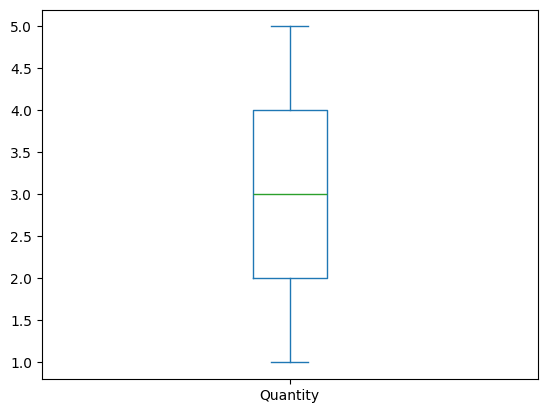

In [13]:
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Quantity'].plot(kind='box')

<Axes: >

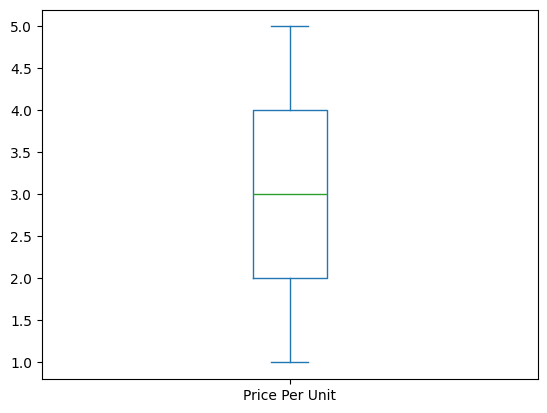

In [14]:
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Price Per Unit'].plot(kind='box')

In [15]:
df['Quantity'].fillna(df['Quantity'].mean(), inplace=True)
df['Price Per Unit'].fillna(df['Price Per Unit'].mean(), inplace=True)
df[['Price Per Unit', 'Quantity']].isnull().sum()

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15812\284157103.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Quantity'].fillna(df['Quantity'].mean(), inplace=True)


Price Per Unit    0
Quantity          0
dtype: int64

In [16]:
df['Total Spent'] = df['Quantity'] * df['Price Per Unit']

In [17]:
df['Payment Method'].fillna('Unkwown', inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_15812\1355868494.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Payment Method'].fillna('Unkwown', inplace=True)


In [18]:
df = df.dropna(subset=['Transaction Date'])
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

In [19]:
df.isnull().sum()

Transaction ID      0
Item                0
Quantity            0
Price Per Unit      0
Total Spent         0
Payment Method      0
Transaction Date    0
dtype: int64

In [20]:
df.shape

(8613, 7)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df = df.sort_values(by='Transaction Date', ascending=True)
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Transaction Date
7306,TXN_6234882,Cookie,4.000000,1.000000,4.000000,Credit Card,2023-01-01
8015,TXN_4801947,Juice,1.000000,3.000000,3.000000,Digital Wallet,2023-01-01
1425,TXN_8842223,Sandwich,5.000000,2.951766,14.758828,Digital Wallet,2023-01-01
768,TXN_5728991,Salad,3.029846,5.000000,15.149228,Unkwown,2023-01-01
1806,TXN_2192787,Sandwich,5.000000,4.000000,20.000000,Cash,2023-01-01


In [23]:
grouped_byPayment_method = df.groupby('Payment Method').agg({
    'Total Spent': 'sum',
    'Quantity': 'sum',
    'Transaction ID': 'count'
}).rename(columns={
    'Total Spent': 'Total Revenue',
    'Quantity': 'Total Item Sold',
    'Transaction ID': 'Total Transactions'
})
grouped_byPayment_method


,Total Revenue,Total Item Sold,Total Transactions
Payment Method,,,
Cash,17808.563384,5953.447335,1956
Credit Card,17521.583303,5874.626408,1949
Digital Wallet,17680.524671,6023.805481,1980
Unkwown,24007.186230,8219.999303,2728


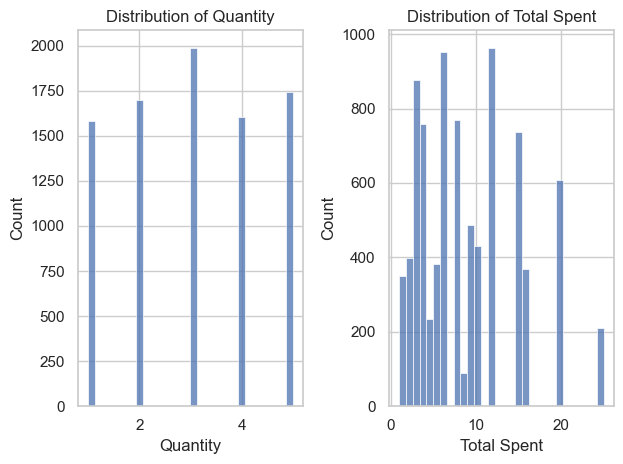

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

plt.subplot(1, 2, 1)
sns.histplot(df['Quantity'], bins=30)
plt.title('Distribution of Quantity')

plt.subplot(1, 2, 2)
sns.histplot(df['Total Spent'], bins=30)
plt.title('Distribution of Total Spent')

plt.tight_layout()
plt.show()

In [25]:
df.to_csv('cleaned_cafe_sales.csv', index=False)